In [11]:
import pandas as pd
import random
import yaml

In [12]:
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)
PARQUET_FILE = config['data']['parquet_file']

In [13]:
# Load the parquet file
df = pd.read_parquet(PARQUET_FILE)
test_df = df[df['split'] == 'test']
videos_test = test_df['video_name'].unique()
train_df = df[df['split'] == 'train']
videos_train = train_df['video_name'].unique()
val_df = df[df['split'] == 'val']
videos_val = val_df['video_name'].unique()
print(f"Unique videos in test set: {len(videos_test)}")
print(f"Unique videos in train set: {len(videos_train)}")
print(f"Unique videos in validation set: {len(videos_val)}")


Unique videos in test set: 20
Unique videos in train set: 61
Unique videos in validation set: 19


In [39]:
random_video_test = random.choice(videos_test)
print(f"Random video from test set: {random_video_test}")

Random video from test set: MVI_39931


Number of frames for MVI_39931: 1270


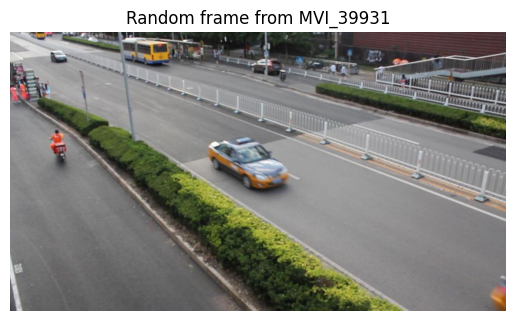

In [44]:
import os
import glob
import matplotlib.pyplot as plt
import cv2

frames_folder = config['data']['frames_folder']
pattern = os.path.join(frames_folder, f"{random_video_test}_img*.jpg")
frame_files = sorted(glob.glob(pattern))
print(f"Number of frames for {random_video_test}: {len(frame_files)}")
random_frame_file = random.choice(frame_files)

plt.imshow(cv2.cvtColor(cv2.imread(random_frame_file), cv2.COLOR_BGR2RGB))
plt.title(f"Random frame from {random_video_test}")
plt.axis('off')
plt.show()